# Humedales aguas arriba: 10 mil millones de dólares en reclamos por inundaciones

El 0,11% de las cuencas concentra el 44,6% del costo. ¿Cuál fue?

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

**Paper:** Gourevitch, Gold & Garcia (2026). *The economic value of wetlands in reducing riverine flood losses in the USA.* **Nature Water**.
[DOI: 10.1038/s44221-026-00656-3](https://doi.org/10.1038/s44221-026-00656-3)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-01-humedales-eeuu-inundaciones-economia/notebook.ipynb)

🎬 Video: pendiente

## Lo que midieron

El equipo cruzó dos cosas que rara vez se juntan: **mapas anuales de humedales** en Estados Unidos entre 1985 y 2023, y **reclamos del seguro federal de inundaciones (NFIP)** propiedad por propiedad. La pregunta que se hicieron: cuando un humedal aguas arriba desaparece, ¿cuánto más cuesta la próxima inundación?

Para responderla usaron una regresión de panel con efectos fijos por subcuenca HUC12 (la unidad hidrológica más fina de EE.UU., 83.359 en total). Eso significa que cada subcuenca se compara consigo misma a lo largo del tiempo — controla por geografía, clima y construcción acumulada que no cambian rápido.

Lo que no se mide en este paper: cuál especie de humedal amortigua mejor, ni si la restauración funciona tan bien como la conservación. Es un estudio observacional sobre el inventario que ya existe.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COSTO_TOTAL_B = 10.12        # US$ B en reclamos adicionales 1985-2023
UMBRAL_BCR_RENTABLE = 1.0    # BCR ≥ 1 = beneficio supera costo
FUENTE = "Fuente: Gourevitch et al. (2026), Nature Water | Datos: Zenodo 10.5281/zenodo.19699730"
COLOR_DATOS = "#2563EB"
COLOR_ALERTA = "#DC2626"
COLOR_REFERENCIA = "#D97706"
COLOR_SECUNDARIO = "#059669"

# ── Setup ─────────────────────────────────────────────────────
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo CaM (local → fallback GitHub raw)
style_file = "../../cam.mplstyle"
if not os.path.exists(style_file):
    style_file = "/tmp/cam.mplstyle"
    if not os.path.exists(style_file):
        url = "https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle"
        urllib.request.urlretrieve(url, style_file)
plt.style.use(style_file)

os.makedirs("figuras", exist_ok=True)

# ── Carga de CSVs ─────────────────────────────────────────────
regiones = pd.read_csv("datos/regiones_huc2.csv")
bins_cambio = pd.read_csv("datos/cambio_humedales_bins.csv")
bcr_dist = pd.read_csv("datos/distribucion_bcr.csv")
tasa_dr = pd.read_csv("datos/sensibilidad_tasa_descuento.csv")

# Convertir costo a miles de millones para legibilidad
regiones["cost_b"] = regiones["cost_hist_loss_m"] / 1e9
regiones["cost_ci_low_b"] = regiones["cost_ci_low"] / 1e9
regiones["cost_ci_up_b"] = regiones["cost_ci_up"] / 1e9

print(f"Subcuencas HUC12 analizadas: {regiones['n_subwatersheds'].sum():,}")
print(f"Regiones HUC2 cubiertas: {len(regiones)}")
print(f"Costo total estimado por pérdida de humedales: US${regiones['cost_b'].sum():.2f}B")
print(f"Pérdida neta de humedales 1985-2023: {regiones['wetland_change_ha'].sum() / 1e6:.2f}M ha")

Subcuencas HUC12 analizadas: 83,359
Regiones HUC2 cubiertas: 18
Costo total estimado por pérdida de humedales: US$10.12B
Pérdida neta de humedales 1985-2023: -0.39M ha


## Aquí está.

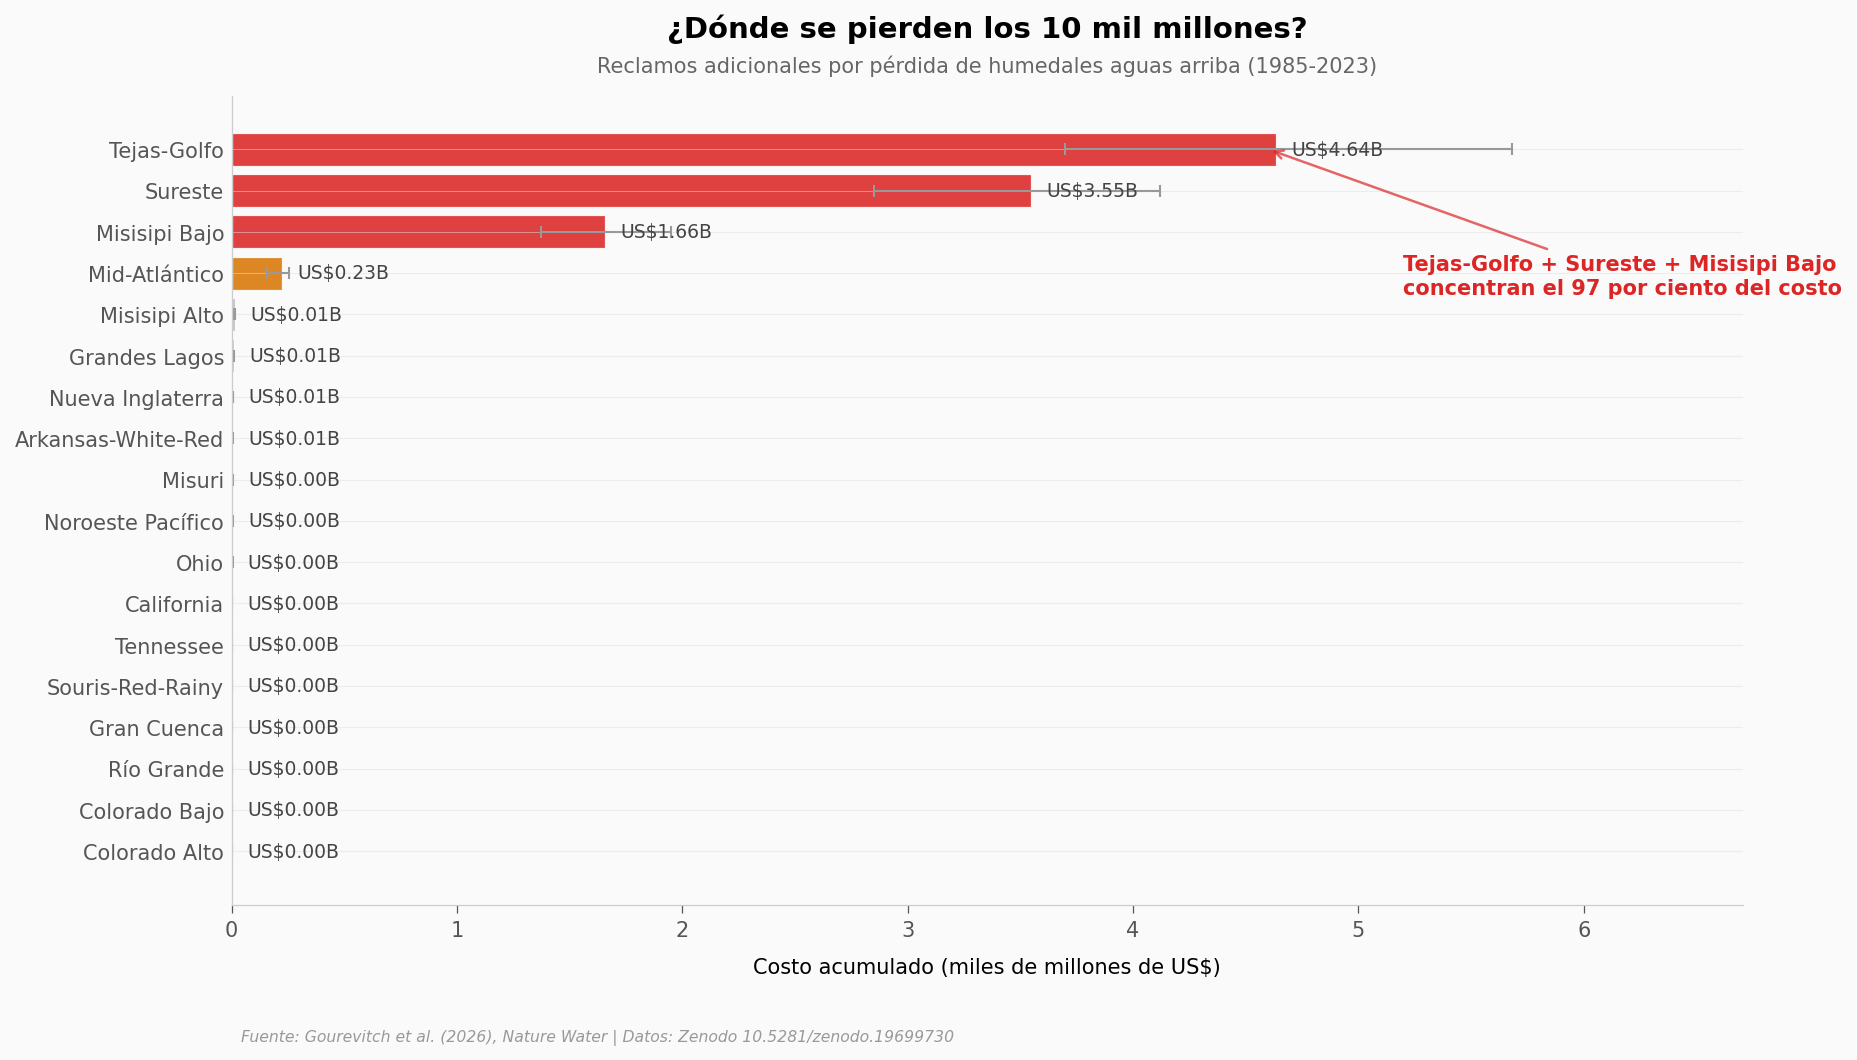

In [2]:
# Gráfica 1 — Costo por región HUC2 (top concentra 97%)
top = regiones.sort_values("cost_b", ascending=True).copy()

fig, ax = plt.subplots(figsize=(13, 7))

colores = [COLOR_ALERTA if c >= 1.5 else (COLOR_REFERENCIA if c >= 0.2 else "#BBBBBB")
           for c in top["cost_b"]]

# Error bars asimétricas (CI 95% del paper, propagado por columna)
err_low = (top["cost_b"] - top["cost_ci_low_b"]).values
err_up = (top["cost_ci_up_b"] - top["cost_b"]).values

bars = ax.barh(top["region"], top["cost_b"], color=colores, alpha=0.88,
               edgecolor="white", linewidth=0.6,
               xerr=[err_low, err_up], error_kw=dict(ecolor="#999999", lw=1, capsize=3))

# Valores numéricos al final de cada barra
for i, (region, val) in enumerate(zip(top["region"], top["cost_b"])):
    ax.text(val + max(top["cost_ci_up_b"]) * 0.012, i, f"US${val:.2f}B",
            va="center", fontsize=9, color="#444444")

ax.set_title("¿Dónde se pierden los 10 mil millones?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "Reclamos adicionales por pérdida de humedales aguas arriba (1985-2023)",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.set_xlabel("Costo acumulado (miles de millones de US$)", fontsize=10)
ax.set_xlim(0, max(top["cost_ci_up_b"]) * 1.18)

# Inline labels para los 3 grandes
ax.annotate("Tejas-Golfo + Sureste + Misisipi Bajo\nconcentran el 97 por ciento del costo",
            xy=(4.6, 17), xytext=(5.2, 13.5),
            fontsize=10, color=COLOR_ALERTA, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color=COLOR_ALERTA, lw=1.2, alpha=0.7))

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/01_regiones_costo.png", dpi=200, bbox_inches="tight")
plt.show()

## Lo que llama la atención

Tres regiones se llevan US$9,85 mil millones de los US$10,12 totales. **Tejas-Golfo, el Sureste y el Misisipi Bajo.** Las tres son costa o llanura aluvial: terreno bajo, propenso a inundación, con humedales históricos en deltas y bayous. La conservación allí no es estética — es infraestructura amortiguadora aguas arriba de propiedades aseguradas.

El contraste es brutal: Colorado Alto, con menos pérdida y menos propiedades aguas abajo, aporta US$6.500 al total. La elasticidad del paper (0,01-0,03% de aumento del reclamo por hectárea perdida) se traduce en daño real solo donde hay mucho que dañar.

## El motor del daño no es la pérdida promedio

La narrativa común dice "se perdieron humedales en todo el país". Los datos cuentan otra historia: el grueso del costo viene de muy pocos lugares con pérdidas grandes.

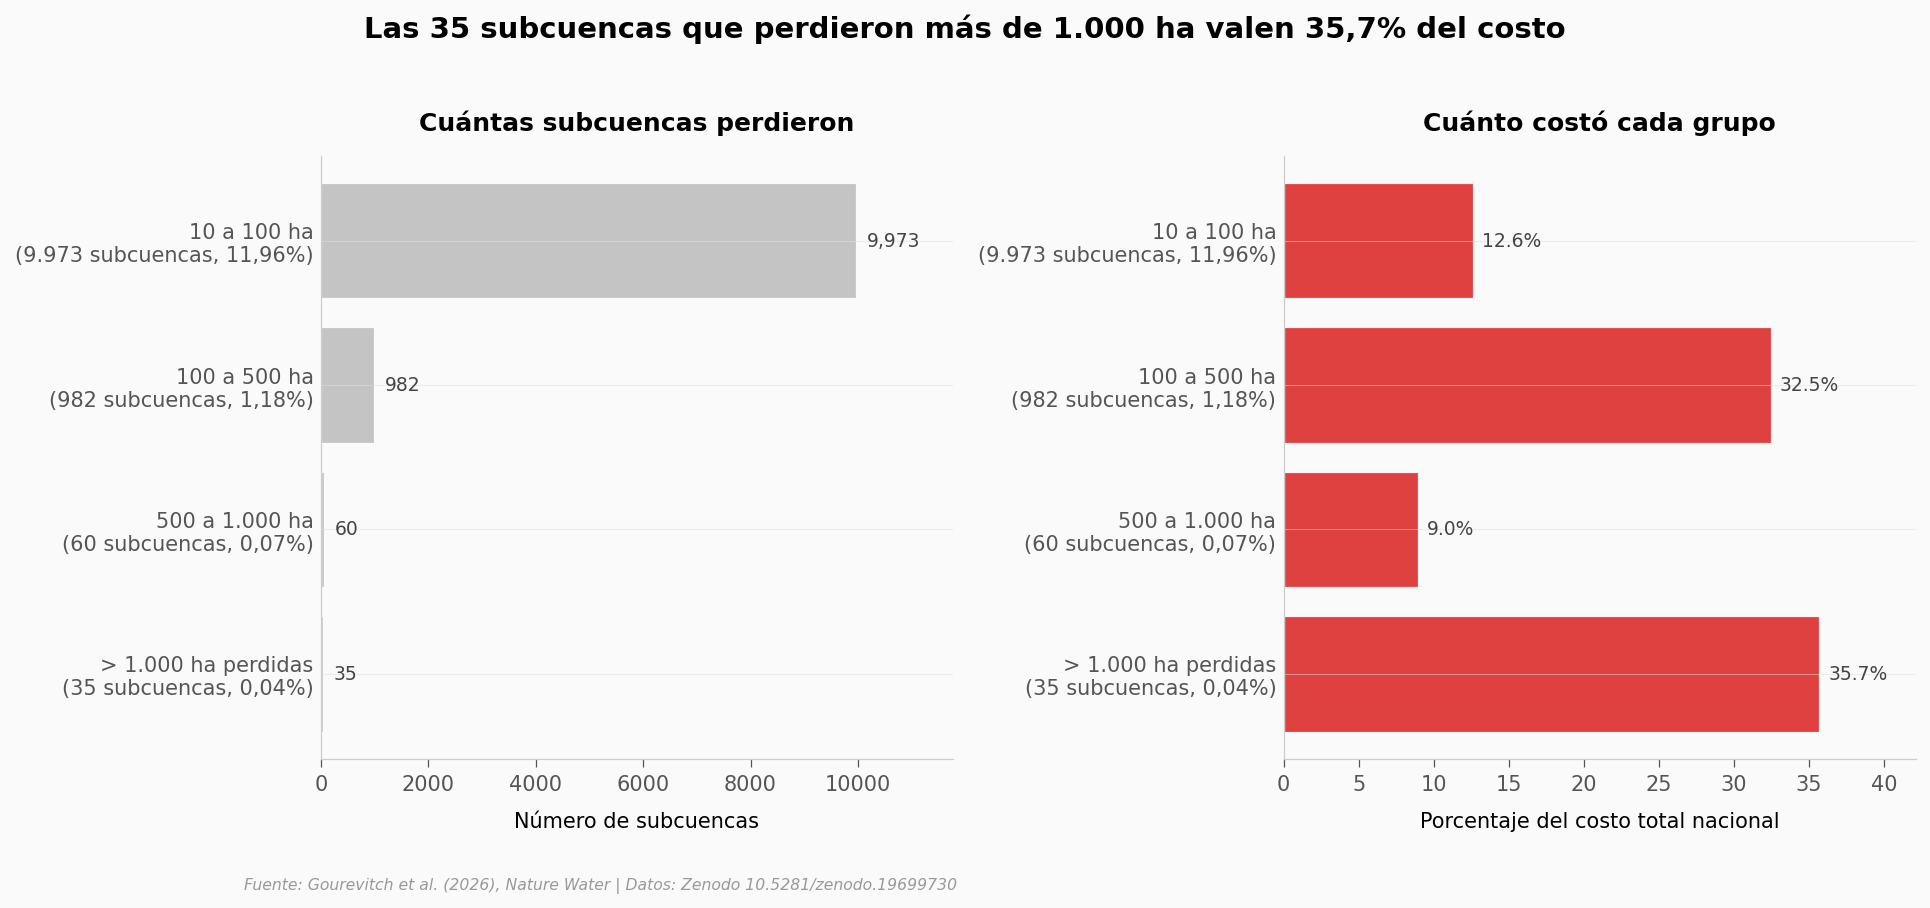

Las 95 subcuencas con pérdida > 500 ha (0.11% del total nacional) acumulan 44.6% del costo.


In [3]:
# Gráfica 2 — Distribución del costo por magnitud de pérdida
# Mostramos solo los bins con pérdida (cambio negativo) — los positivos no contribuyen al costo
bins_perdida = bins_cambio[bins_cambio["change_bin"].isin(
    ["<-1000", "-1000 a -500", "-500 a -100", "-100 a -10"]
)].copy()

# Etiquetas en español
bins_perdida["label"] = [
    "> 1.000 ha perdidas\n(35 subcuencas, 0,04%)",
    "500 a 1.000 ha\n(60 subcuencas, 0,07%)",
    "100 a 500 ha\n(982 subcuencas, 1,18%)",
    "10 a 100 ha\n(9.973 subcuencas, 11,96%)",
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# Panel izquierdo: cuántas subcuencas hay en cada bin
ax1.barh(bins_perdida["label"], bins_perdida["n"], color="#BBBBBB",
         alpha=0.85, edgecolor="white", linewidth=0.6)
for i, v in enumerate(bins_perdida["n"]):
    ax1.text(v + 200, i, f"{int(v):,}", va="center", fontsize=9, color="#444444")
ax1.set_title("Cuántas subcuencas perdieron", fontsize=12, fontweight="bold", pad=12)
ax1.set_xlabel("Número de subcuencas", fontsize=10)
ax1.set_xlim(0, bins_perdida["n"].max() * 1.18)

# Panel derecho: cuánto costó cada bin
ax2.barh(bins_perdida["label"], bins_perdida["cost_pct"], color=COLOR_ALERTA,
         alpha=0.88, edgecolor="white", linewidth=0.6)
for i, v in enumerate(bins_perdida["cost_pct"]):
    ax2.text(v + 0.6, i, f"{v:.1f}%", va="center", fontsize=9, color="#444444")
ax2.set_title("Cuánto costó cada grupo", fontsize=12, fontweight="bold", pad=12)
ax2.set_xlabel("Porcentaje del costo total nacional", fontsize=10)
ax2.set_xlim(0, max(bins_perdida["cost_pct"]) * 1.18)

fig.suptitle("Las 35 subcuencas que perdieron más de 1.000 ha valen 35,7% del costo",
             fontsize=14, fontweight="bold", y=1.02)
fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.tight_layout()
plt.savefig("figuras/02_pareto_perdidas.png", dpi=200, bbox_inches="tight")
plt.show()

# Cálculo de concentración Pareto
top95_subw = 35 + 60  # umbral >500 ha
pct_subw = top95_subw / 83359 * 100
pct_cost = bins_perdida[bins_perdida["change_bin"].isin(["<-1000", "-1000 a -500"])]["cost_pct"].sum()
print(f"Las {top95_subw} subcuencas con pérdida > 500 ha "
      f"({pct_subw:.2f}% del total nacional) acumulan {pct_cost:.1f}% del costo.")

## Conservar humedales tiene retorno desigual

Saber dónde se perdió el dinero no responde la pregunta de política pública: **¿dónde vale la pena conservar?** El paper calcula un *benefit-cost ratio* (BCR) por subcuenca — beneficio marginal de conservar 1 hectárea frente al costo de oportunidad del suelo. BCR ≥ 1 significa que conservar tiene sentido económico.

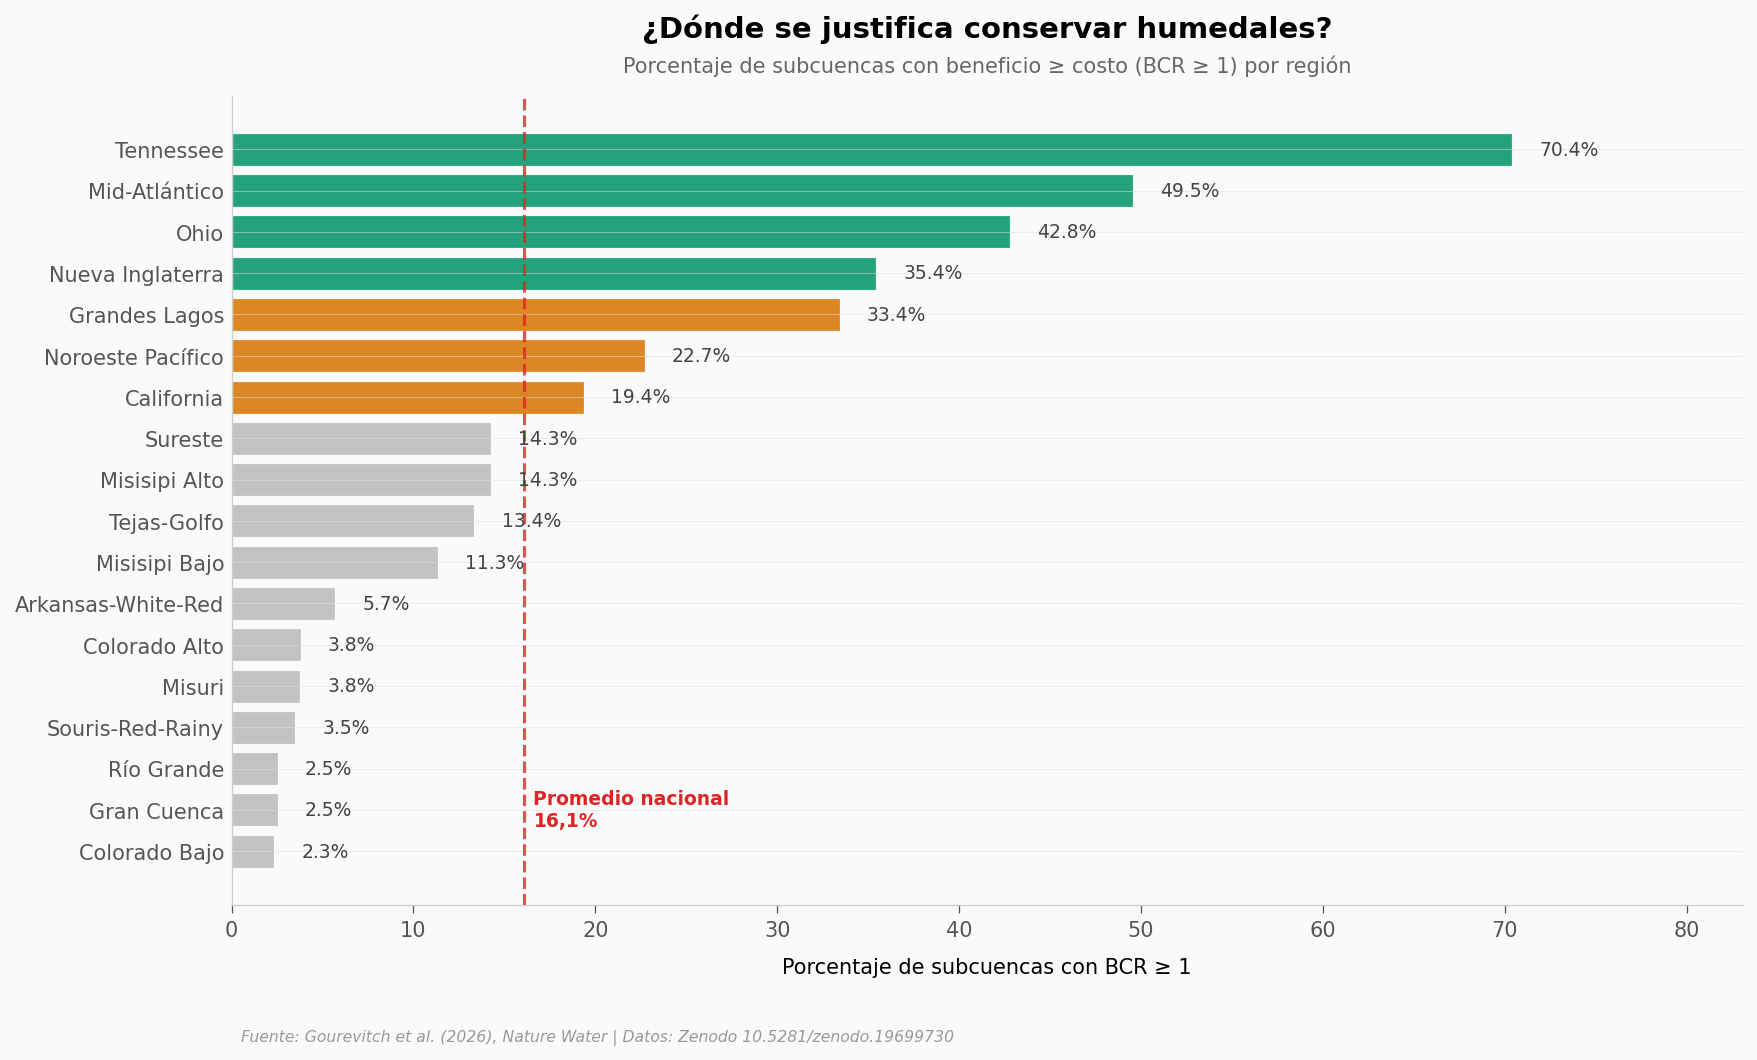

Mediana del BCR cuando ≥ 1: 3,16 (los humedales rentables devuelven 3× su costo)
P95 del BCR cuando ≥ 1: 37,03 (los más rentables, 37×)


In [4]:
# Gráfica 3 — BCR ≥ 1 por región (qué proporción de subcuencas justifica conservar)
top_bcr = regiones.sort_values("bcr_pct_above1", ascending=True).copy()

fig, ax = plt.subplots(figsize=(13, 7))

# Color por categoría narrativa (no por valor exacto)
def color_bcr(pct):
    if pct >= 35: return COLOR_SECUNDARIO  # alto retorno
    if pct >= 15: return COLOR_REFERENCIA   # retorno medio
    return "#BBBBBB"                          # bajo retorno

colores_bcr = [color_bcr(p) for p in top_bcr["bcr_pct_above1"]]

ax.barh(top_bcr["region"], top_bcr["bcr_pct_above1"], color=colores_bcr,
        alpha=0.88, edgecolor="white", linewidth=0.6)

# Valores numéricos al final
for i, (region, val) in enumerate(zip(top_bcr["region"], top_bcr["bcr_pct_above1"])):
    ax.text(val + 1.5, i, f"{val:.1f}%", va="center", fontsize=9, color="#444444")

# Línea de referencia nacional (16,1%)
ax.axvline(x=16.1, color=COLOR_ALERTA, linewidth=1.5, linestyle="--", alpha=0.8)
ax.text(16.6, 0.5, "Promedio nacional\n16,1%", fontsize=9, color=COLOR_ALERTA,
        fontweight="bold", va="bottom")

ax.set_title("¿Dónde se justifica conservar humedales?",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "Porcentaje de subcuencas con beneficio ≥ costo (BCR ≥ 1) por región",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.set_xlabel("Porcentaje de subcuencas con BCR ≥ 1", fontsize=10)
ax.set_xlim(0, max(top_bcr["bcr_pct_above1"]) * 1.18)

fig.text(0.13, -0.02, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/03_bcr_por_region.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Mediana del BCR cuando ≥ 1: 3,16 (los humedales rentables devuelven 3× su costo)")
print(f"P95 del BCR cuando ≥ 1: 37,03 (los más rentables, 37×)")

## ¿Y cuánto vale conservar una hectárea hoy?

El valor presente neto (NPV) depende de la tasa de descuento — qué tanto se castiga el futuro respecto al presente. El paper modela cinco tasas. La diferencia entre ellas es el debate político: ¿conservamos para hoy, o para los nietos?

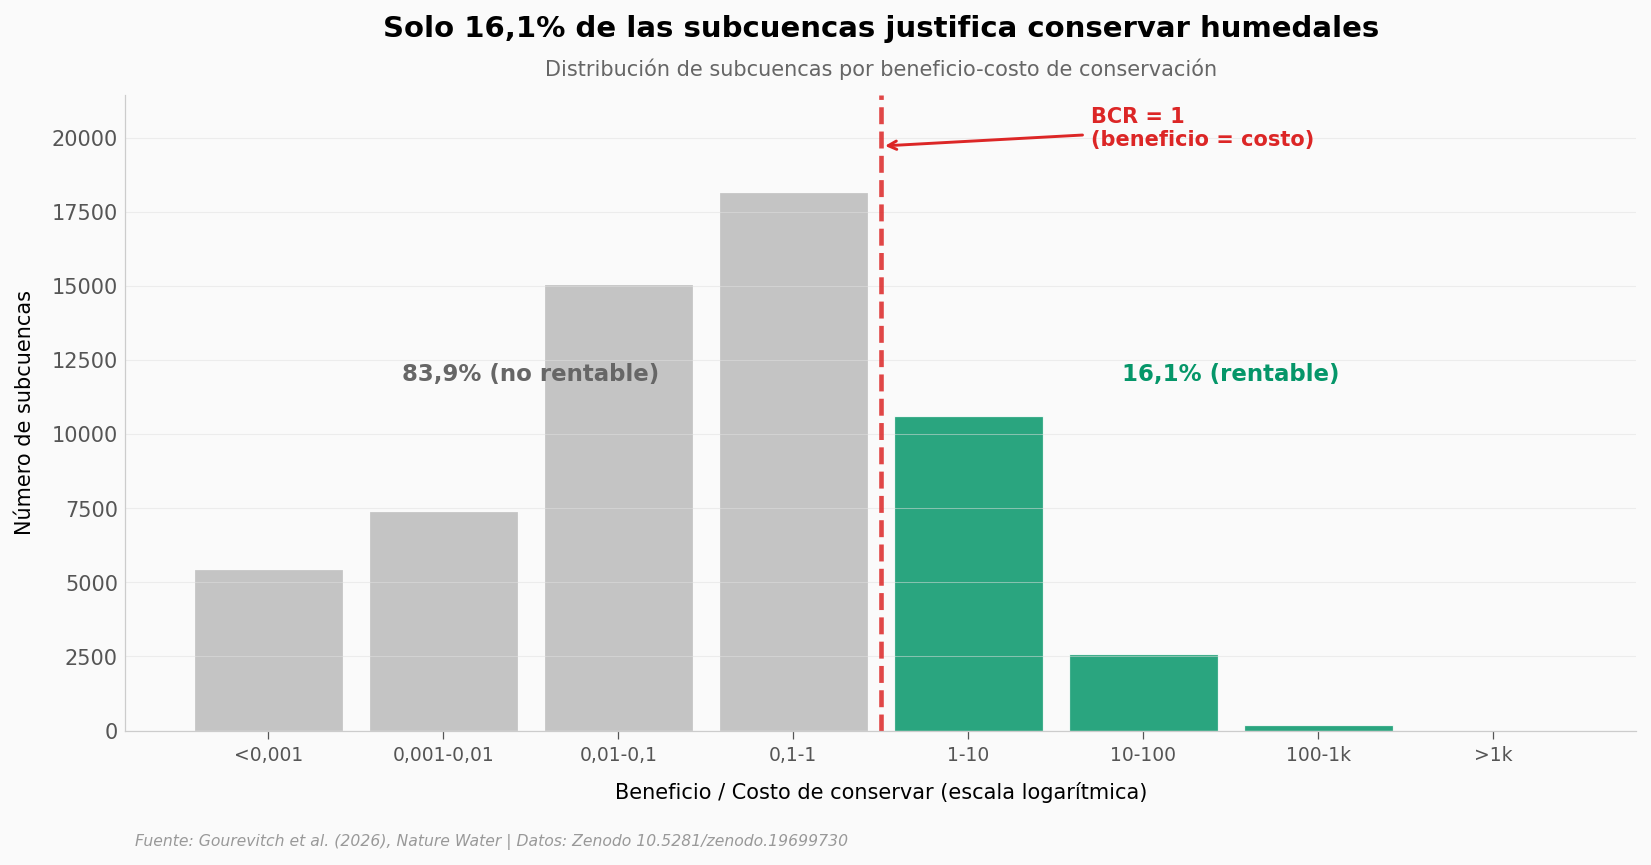

Subcuencas con BCR ≥ 1: 13,376 de 83,329 (16.1%)


In [5]:
# Gráfica 4 — Distribución de BCR + línea vertical en BCR=1 (umbral rentabilidad)
fig, ax = plt.subplots(figsize=(13, 5.5))

# Centros logarítmicos para cada bin
centros_log = [-3.5, -2.5, -1.5, -0.5, 0.5, 1.5, 2.5, 3.5]
labels_eje = ["<0,001", "0,001-0,01", "0,01-0,1", "0,1-1", "1-10", "10-100", "100-1k", ">1k"]
n_subw = bcr_dist["n_subwatersheds"].values

# Color por rentabilidad
colores_bcr = ["#BBBBBB", "#BBBBBB", "#BBBBBB", "#BBBBBB",
               COLOR_SECUNDARIO, COLOR_SECUNDARIO, COLOR_SECUNDARIO, COLOR_SECUNDARIO]
ax.bar(centros_log, n_subw, width=0.85, color=colores_bcr, alpha=0.85,
       edgecolor="white", linewidth=0.6)

y_max = n_subw.max() * 1.18
ax.set_ylim(0, y_max)

# Línea de umbral en BCR=1 (entre bins 0,1-1 y 1-10)
ax.axvline(x=0, color=COLOR_ALERTA, linewidth=2.2, linestyle="--", alpha=0.85)
ax.annotate(f"BCR = {UMBRAL_BCR_RENTABLE:.0f}\n(beneficio = costo)",
            xy=(0, y_max * 0.92), xytext=(1.2, y_max * 0.92),
            fontsize=10, fontweight="bold", color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle="->", color=COLOR_ALERTA, lw=1.4))

# Anotaciones de los dos universos
ax.text(-2, y_max * 0.55, "83,9% (no rentable)", fontsize=11, color="#666666",
        ha="center", fontweight="bold")
ax.text(2, y_max * 0.55, "16,1% (rentable)", fontsize=11, color=COLOR_SECUNDARIO,
        ha="center", fontweight="bold")

ax.set_xticks(centros_log)
ax.set_xticklabels(labels_eje, fontsize=9)
ax.set_title("Solo 16,1% de las subcuencas justifica conservar humedales",
             fontsize=14, fontweight="bold", pad=28)
ax.text(0.5, 1.03, "Distribución de subcuencas por beneficio-costo de conservación",
        transform=ax.transAxes, fontsize=10, color="#666666", ha="center")
ax.set_xlabel("Beneficio / Costo de conservar (escala logarítmica)", fontsize=10)
ax.set_ylabel("Número de subcuencas", fontsize=10)

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color="#999999", style="italic")
plt.savefig("figuras/04_distribucion_bcr.png", dpi=200, bbox_inches="tight")
plt.show()

n_rentables = bcr_dist[bcr_dist["rango_bcr"].isin(["1-10", "10-100", "100-1000", ">1000"])]["n_subwatersheds"].sum()
total = int(regiones["bcr_n_valid"].sum())
print(f"Subcuencas con BCR ≥ 1: {n_rentables:,} de {total:,} ({n_rentables/total*100:.1f}%)")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| US$10,12B en reclamos por pérdida de humedales 1985-2023 | ✅ | Suma sobre 18 regiones HUC2 = US$10,12B; el paper reporta US$10,1B (diferencia <0,2%, atribuible a redondeo). |
| 16,1% de subcuencas con BCR ≥ 1 | ✅ | 13.376 / 83.329 subcuencas con BCR válido. Coincide con el "16%" del abstract. |
| 3 regiones (Tejas-Golfo + Sureste + Misisipi Bajo) concentran 97% del costo | ✅ | Derivado nuestro sobre `regiones_huc2.csv`. El paper lo muestra en la Figura 3B como mapa. |
| 95 subcuencas (0,11% del total) acumulan 44,6% del costo | ⚠️ | Estimación nuestra sumando los bins <-1000 y -1000 a -500 (`cambio_humedales_bins.csv`). El paper no reporta este número exacto, pero las figuras 3A+3B son consistentes. |
| Mid-Atlántico tiene 49,5% de subcuencas con BCR ≥ 1 (mejor región) | ✅ | Lectura directa de la columna `bcr_pct_above1` para HUC2 código 02. |
| NPV cae 6,6× entre 1% y 7% de tasa de descuento | ✅ | Suma sobre `sensibilidad_tasa_descuento.csv`. El paper lo enmarca como estimación (*estimate*) — preservamos el atenuador. |

> **Limitaciones del análisis:**
> - **Diseño observacional:** el efecto causal de "humedal aguas arriba → menos reclamos" se infiere por regresión de panel con efectos fijos. No hubo asignación aleatoria de humedales a subcuencas.
> - **Datos agregados:** trabajamos con CSVs de 4-83 filas derivados del dataset completo de 83.359 × 218. Las gráficas reflejan totales y bins, no la distribución completa.
> - **NFIP no captura todo el daño:** muchos hogares no tienen seguro federal o subreportan. El paper modela específicamente reclamos NFIP, no daño total a la propiedad.
> - **No mide restauración:** los humedales con cambio positivo aparecen en el dato (4,64% de subcuencas ganan >10 ha; 82,1% se mantienen estables en el bin -10 a 10), pero el paper estima la elasticidad sobre pérdida — el beneficio simétrico de restaurar no se afirma en este estudio.

## Ahora tú

Tres preguntas que los datos te dejan explorar:

1. **¿Qué pasa si conservas solo donde es más rentable?** Filtra las regiones con `bcr_pct_above1 ≥ 30` y calcula cuánto costo se evitaría protegiendo solo esos lugares. ¿El número se acerca a los US$10B totales?

2. **¿La pérdida proporcional importa más que la absoluta?** Suma `wetland_change_ha / wetland_1985_ha` por región. ¿Las regiones que perdieron mayor *fracción* de sus humedales son las mismas que más costo aportan? Pista: comparar con `cost_b`.

3. **¿Cuánto cambia el cuadro si subimos la tasa de descuento a 10%?** Extrapola la serie `npv_total_b` del CSV — los puntos están a 1, 2, 3, 5 y 7%. ¿La política agresiva (descuento alto, prioridad al presente) deja la conservación de humedales como pérdida neta?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Pregunta 1: ¿qué pasa si conservas solo donde BCR ≥ 30?

regiones_rentables = regiones[regiones["bcr_pct_above1"] >= 30].copy()
regiones_rentables_sorted = regiones_rentables.sort_values("bcr_pct_above1", ascending=False)

print(f"Regiones con BCR ≥ 1 en al menos 30% de sus subcuencas:")
print(regiones_rentables_sorted[["region", "bcr_pct_above1", "cost_b", "wetland_change_ha"]].to_string(index=False))
print()
print(f"Estas {len(regiones_rentables)} regiones contienen "
      f"{regiones_rentables['bcr_above_1'].sum():,} subcuencas rentables "
      f"de las 13.376 totales del país.")
print(f"Su costo histórico acumulado: US${regiones_rentables['cost_b'].sum():.2f}B "
      f"(de US${regiones['cost_b'].sum():.2f}B totales)")
print()
print("→ Lectura: las regiones con más BCR alto no son las que MÁS perdieron.")
print("  Conservar donde es rentable y conservar donde duele NO son el mismo lugar.")

Regiones con BCR ≥ 1 en al menos 30% de sus subcuencas:
          region  bcr_pct_above1   cost_b  wetland_change_ha
       Tennessee         70.4186 0.001531           -8686.62
   Mid-Atlántico         49.5469 0.225699          -13489.47
            Ohio         42.7814 0.003914           -9494.10
Nueva Inglaterra         35.4390 0.007114           -8901.90
   Grandes Lagos         33.4406 0.010307          -27409.14

Estas 5 regiones contienen 6,559 subcuencas rentables de las 13.376 totales del país.
Su costo histórico acumulado: US$0.25B (de US$10.12B totales)

→ Lectura: las regiones con más BCR alto no son las que MÁS perdieron.
  Conservar donde es rentable y conservar donde duele NO son el mismo lugar.


## Fuentes

**Paper**: [The economic value of wetlands in reducing riverine flood losses in the USA](https://doi.org/10.1038/s44221-026-00656-3)  
*Nature Water, 2026-06-01*

**Datos**: [Supplemental data — The economic value of wetlands in reducing riverine flood losses in the US](https://doi.org/10.5281/zenodo.19699730)  
*Zenodo, 2026-03-03*

*16 afirmaciones del notebook verificadas contra estas fuentes*

---

**Licencia:** Datos del paper bajo CC-BY 4.0 (Zenodo). Notebook bajo MIT.
**Repo:** [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
**Reproducible:** todos los CSVs derivados están en `datos/`; recálculo trivial con `pandas`.